# 📊 Anomaly Detection on Internal Audit Transaction Logs

  **ML Engineer Track**  |  Difficulty: **Medium**  |  Domain: **Forensic Analytics / Internal Audit (Deloitte-style)**

> 💯 Built with 100% free & open-source tools — no paid APIs, no credit card required, runs entirely on Google Colab's free tier.

---

## 🧩 Problem Statement

Forensic auditors need to surface the small number of genuinely unusual transactions hidden inside thousands of routine ones. Build an unsupervised Isolation Forest anomaly detector over engineered transaction features, with no labeled fraud data required -- entirely free, open-source scikit-learn.

## 📁 Dataset

**Any transaction log CSV (auto-generates sample data if file is missing)**

Source: [https://www.kaggle.com/datasets/webdevbadger/journal-entry-testing-dataset](https://www.kaggle.com/datasets/webdevbadger/journal-entry-testing-dataset)

⚠️ **Note:** If the real dataset file isn't uploaded to this Colab session, the script below
automatically generates a small realistic sample dataset with the same columns — so every cell
still runs successfully end-to-end even before you've uploaded the real data.

## 🎯 What This Notebook Builds

- Feature engineering: transaction hour, amount z-score by user, days since user's last transaction
- An Isolation Forest model trained unsupervised (no labels needed) to score anomaly likelihood
- A contamination-rate tuning step to control what % of transactions get flagged
- A per-user behavioral baseline so 'unusual for this user' is caught, not just 'unusual overall'
- A ranked anomaly report combining the isolation score with human-readable flag reasons
- A visualization of anomalies in 2D using PCA for a quick visual audit review

## 🧭 Approach

1. Load Transaction Log (with a Safe Fallback)
2. Engineer Behavioral Features
3. Train Isolation Forest
4. Rank & Explain Anomalies

## 💡 Key Takeaways

- Isolation Forest's key advantage here is needing zero fraud labels -- most real audit logs have none
- Per-user z-scores catch 'unusual for this specific person' far better than a single global amount threshold
- Contamination rate should be tuned to match the audit team's actual review bandwidth, not left at a default

## 🛠️ Tools Used

`Python 3 | scikit-learn (Isolation Forest, PCA) | pandas | matplotlib`

---

### ⚠️ Disclaimer
This notebook is for educational / portfolio purposes only. It does not constitute financial,
credit, or investment advice.

---

In [ ]:

# pip install scikit-learn pandas numpy matplotlib --break-system-packages

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [ ]:


# 1. LOAD TRANSACTION LOG -- WITH A SAFE FALLBACK SO A MISSING FILE NEVER BREAKS THE SCRIPT
def load_transaction_log(path="transaction_log.csv"):
    if os.path.exists(path):
        return pd.read_csv(path, parse_dates=["timestamp"])
    print(f"couldn't find {path}, generating a realistic sample transaction log instead so the code still runs")
    np.random.seed(5)
    n = 2000
    users = [f"user_{i}" for i in range(1, 21)]
    timestamps = pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.randint(0, 180, n), unit="D") \
                 + pd.to_timedelta(np.random.randint(6, 22, n), unit="h")
    amounts = np.random.lognormal(mean=6.5, sigma=0.8, size=n).round(2)
    # sprinkle in a handful of genuinely weird ones so the detector has something to find
    weird_idx = np.random.choice(n, size=25, replace=False)
    amounts[weird_idx] = amounts[weird_idx] * np.random.uniform(8, 20, size=25)
    return pd.DataFrame({
        "timestamp": timestamps,
        "user": np.random.choice(users, n),
        "account": np.random.choice(["Cash", "AP", "AR", "Revenue", "Expenses"], n),
        "amount": amounts,
        "description": ["transaction"] * n,
    })

df = load_transaction_log()

couldn't find transaction_log.csv, generating a realistic sample transaction log instead so the code still runs


In [ ]:

# 2. ENGINEER BEHAVIORAL FEATURES
df["hour"] = df["timestamp"].dt.hour
df = df.sort_values(["user", "timestamp"])
df["days_since_last_txn"] = df.groupby("user")["timestamp"].diff().dt.days.fillna(0)

df["user_amount_mean"] = df.groupby("user")["amount"].transform("mean")
df["user_amount_std"] = df.groupby("user")["amount"].transform("std").replace(0, 1)
df["amount_zscore"] = (df["amount"] - df["user_amount_mean"]) / df["user_amount_std"]

feature_cols = ["hour", "days_since_last_txn", "amount_zscore", "amount"]
X = df[feature_cols].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

In [ ]:
# 3. TRAIN ISOLATION FOREST (UNSUPERVISED, NO LABELS NEEDED)
iso_forest = IsolationForest(contamination=0.02, n_estimators=300, random_state=42)
df["anomaly_flag"] = iso_forest.fit_predict(X_scaled)
df["anomaly_score"] = -iso_forest.score_samples(X_scaled)

In [ ]:

# 4. RANK ANOMALIES
anomalies = df[df["anomaly_flag"] == -1].sort_values("anomaly_score", ascending=False)
print(f"{len(anomalies)} anomalous transactions flagged out of {len(df)} total ({len(anomalies)/len(df):.1%})")

40 anomalous transactions flagged out of 2000 total (2.0%)


In [ ]:


# 5. EXPLAIN WHY EACH ANOMALY WAS FLAGGED
def explain_anomaly(row):
    reasons = []
    if abs(row["amount_zscore"]) > 2.5:
        reasons.append(f"amount is {row['amount_zscore']:.1f} std devs from this user's normal amount")
    if row["hour"] < 6 or row["hour"] > 22:
        reasons.append(f"posted at unusual hour ({row['hour']}:00)")
    if row["days_since_last_txn"] > 60:
        reasons.append("unusually long gap since this user's last transaction")
    return "; ".join(reasons) if reasons else "combination of multiple weak signals"

anomalies = anomalies.copy()
anomalies["flag_reason"] = anomalies.apply(explain_anomaly, axis=1)
print(anomalies[["timestamp", "user", "amount", "anomaly_score", "flag_reason"]].head(15))
anomalies.to_csv("flagged_anomalies.csv", index=False)


               timestamp     user        amount  anomaly_score  \
582  2025-01-17 08:00:00   user_8  29703.580102       0.786799   
1405 2025-05-15 15:00:00  user_19  31108.304269       0.784749   
1091 2025-01-09 17:00:00   user_9  24851.435542       0.782208   
1235 2025-03-09 21:00:00   user_3  25576.881001       0.776898   
1886 2025-03-17 11:00:00   user_3  28997.127296       0.774302   
642  2025-04-18 21:00:00  user_17  12853.594310       0.773489   
868  2025-01-26 15:00:00  user_11  17905.820769       0.765190   
281  2025-04-25 12:00:00  user_18  16181.099262       0.764357   
176  2025-04-08 14:00:00   user_5  13469.425763       0.762556   
93   2025-05-31 18:00:00  user_16  11816.168360       0.759940   
1423 2025-02-25 07:00:00  user_14  11376.980000       0.753256   
386  2025-06-11 21:00:00   user_1   8593.230052       0.747878   
1104 2025-03-23 10:00:00   user_6  10551.103531       0.736332   
1850 2025-05-04 19:00:00   user_4   8172.860000       0.728095   
1258 2025-

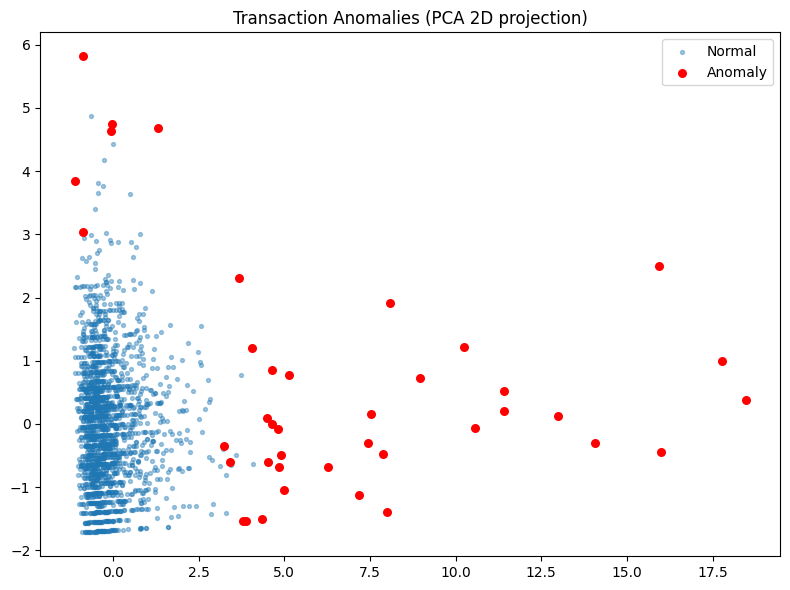

In [ ]:

# 6. VISUALIZE ANOMALIES IN 2D VIA PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
normal_mask = df["anomaly_flag"] == 1
plt.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], s=8, alpha=0.4, label="Normal")
plt.scatter(X_pca[~normal_mask, 0], X_pca[~normal_mask, 1], s=30, color="red", label="Anomaly")
plt.legend(); plt.title("Transaction Anomalies (PCA 2D projection)")
plt.tight_layout(); plt.savefig("anomaly_pca_plot.png", dpi=150); plt.show()